In [254]:
from langchain_qdrant import QdrantVectorStore, FastEmbedSparse, SparseEmbeddings
from qdrant_client import QdrantClient
from dotenv import load_dotenv
import os

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_tavily import TavilySearch

from langchain_core.tools import Tool
from dataclasses import dataclass

from pydantic import BaseModel, Field
from typing import List, Annotated, Sequence
from langchain_core.messages import AnyMessage, AIMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from pprint import pprint

from IPython.display import display, Image

In [255]:
client = QdrantClient(
    url=os.getenv('QDRANT_API_URL'),
    api_key= os.getenv('QDRANT_API_KEY')
)

In [256]:
dense_embedding = HuggingFaceEmbeddings(model = 'sentence-transformers/all-MiniLM-L12-v2')
sparse_embedding = FastEmbedSparse(model_name='Qdrant/bm25')

In [257]:
qdrantdb = QdrantVectorStore(
    client=client,
    collection_name= os.getenv('COLLECTIONNAME'),
    embedding= dense_embedding,
    sparse_embedding= sparse_embedding
)

In [258]:
qdrantdb_retriver = qdrantdb.as_retriever(
    search_type = 'mmr',
    search_kwarg = {
        "k":3
    }
)
qdrantdb_retriver.invoke("Create Test Measure for Same Period Last Year")

[Document(metadata={'created_date': '2025-11-13 17:16:45', 'author': '', 'tags': 'DAX Questions.pdf', 'producer': 'Skia/PDF m144 Google Docs Renderer', 'creator': '', 'creationdate': '', 'source': '..\\data\\PowerBI\\DAX Questions.pdf', 'file_path': '..\\data\\PowerBI\\DAX Questions.pdf', 'total_pages': 12, 'format': 'PDF 1.4', 'title': '31. What is DAX, and why is it important in Power...', 'subject': '', 'keywords': '', 'moddate': '', 'trapped': '', 'modDate': '', 'creationDate': '', 'page': 6, '_id': '2dc911b3-1ea7-4b82-88b7-dfc6458f3364', '_collection_name': 'PowerBIChat'}, page_content="Write a DAX measure to calculate year-to-date (YTD) sales. Using the TOTALYTD function (which wraps CALCULATE and DATESYTD): Code snippet Sales YTD = TOTALYTD(SUM('Sales'[Amount]), 'Date'[Date])\u200b 42. Write a DAX measure to calculate the difference between current year sales and previous year sales. Code snippet"),
 Document(metadata={'created_date': '2025-11-13 17:16:45', 'author': '', 'tags':

In [259]:
def getPowerBIQuestionAnswers(query : str) -> str:

    docs = qdrantdb_retriver.invoke(query)
    return '\n\n'.join([doc.page_content for doc in docs])

powerbi_qns_tool = Tool(
    name = "getPowerBIQuestionAnswers",
    description= "get PowerBI Question Answers from qdrant DB",
    func= getPowerBIQuestionAnswers
)

In [260]:
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results= 5, doc_content_chars_max=2000))
tivily_tool = TavilySearch(
    max_results=5,
    topic="general",
)


In [261]:
tools = [ powerbi_qns_tool]

In [262]:
@dataclass
class PBIBot:
    messages: Annotated[List[AnyMessage], add_messages]

In [263]:
def agent(state: PBIBot):
    """ 
    Represents the core agent node in a LangGraph workflow.

    This function is responsible for determining the next course of action based on the
    current conversation history (state). It decides whether to generate a final response
    or use one of the provided tools (which can include retrieval tools or general tools).

    Args:
        state: The current conversation history, represented as a list of LangChain
               `BaseMessage` objects. This is the input to the agent's decision-making
               process.
    
    Returns:
        A list containing the new message(s) generated by the agent or the results
        from the executed tools. The state update logic in LangGraph handles appending
        these new messages to the overall conversation history.
    """
    print("---CALL AGENT---")
    # messages = state.messages
    # print(messages)

    llm = ChatGroq(model="openai/gpt-oss-20b")
    llm_tools = llm.bind_tools(tools)
    
    # response = llm_tools.invoke(state.messages)
    msg = llm_tools.invoke(state.messages)
    # print(msg)
    # print(response)
    # # We return a list, because this will get added to the existing list
    return PBIBot(messages=msg)

In [264]:
def reviewNode(state: PBIBot):

    """
    Validates an LLM-generated answer and determines the next step in the workflow.

    This function serves as a conditional edge within a state-based workflow.
    It analyzes the most recent answer generated by the LLM (Large Language Model)
    against the original message/query present in the state. If the answer does
    not meet predefined quality or completeness criteria, the node triggers a
    refinement step where the original question is enhanced. Otherwise, it
    signals the workflow to proceed to the final step.

    Args:
        state: The current state of the workflow, expected to be a dictionary
               containing at least the following keys:
               - 'message': The original user query or prompt.
               - 'answer': The LLM's generated response.

    Returns:
        A string representing the name of the next node to execute (the conditional edge):
        - 'enhance_question': If the 'answer' is deemed unsatisfactory and needs
                              to be improved or re-generated.
        - 'finish': If the 'answer' is satisfactory and the workflow should terminate.
    """

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    print('--Review Node---')
    msg = state.messages
    print("-1",msg[-1])
    print('0',msg[0])
    print('1', msg[1])


In [265]:
from langgraph.graph import StateGraph, START, END

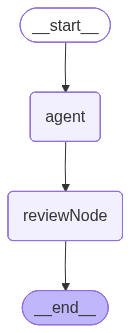

In [266]:
graph = StateGraph(PBIBot)

graph.add_node("agent",agent)
graph.add_node("reviewNode", reviewNode)

graph.add_edge(START, "agent")
graph.add_edge("agent", "reviewNode")
graph.add_edge("reviewNode", END)


graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [272]:
result = graph_builder.invoke(PBIBot(messages=[HumanMessage("What is Power BI")]))


---CALL AGENT---
--Review Node---
-1 content='' additional_kwargs={'reasoning_content': 'The user asks: "What is Power BI". They want a brief explanation. We have a tool to get PowerBI question answers from qdrant DB. Probably we should use that tool to get answer. The tool signature: getPowerBIQuestionAnswers with __arg1 string. Likely we need to pass the question. So we should call the function with __arg1: "What is Power BI". Then respond with result.', 'tool_calls': [{'id': 'fc_ff855536-9b6d-4226-aca6-0fa1c3cfe403', 'function': {'arguments': '{"__arg1":"What is Power BI"}', 'name': 'getPowerBIQuestionAnswers'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 120, 'prompt_tokens': 138, 'total_tokens': 258, 'completion_time': 0.129310931, 'completion_tokens_details': {'reasoning_tokens': 89}, 'prompt_time': 0.011496304, 'prompt_tokens_details': None, 'queue_time': 0.057718896, 'total_time': 0.140807235}, 'model_name': 'openai/gpt-oss-20b', 'system_finger

In [268]:
result = graph_builder.invoke(PBIBot(messages=[HumanMessage("What is Power BI DAX")]))


---CALL AGENT---
--Review Node---
-1 content='**Power\u202fBI DAX (Data Analysis Expressions)** is the formula language used in Power\u202fBI, Power\u202fPivot, and Analysis Services Tabular models to create calculated columns, measures, and custom tables.  \n\n| What it is | Why it matters |\n|------------|----------------|\n| **A declarative language** – you describe *what* you want (e.g., a total sales figure) rather than *how* to compute it. | Lets you build powerful, reusable calculations that update automatically when data changes. |\n| **Built on Excel‑style formulas** – many functions (SUM, IF, CALCULATE, RELATED, etc.) look familiar to Excel users. | Lowers the learning curve for people coming from Excel. |\n| **Context‑aware** – calculations run in the context of rows, filters, or slicers. | Enables dynamic, interactive visuals that respond to user selections. |\n| **Three main types of objects** | |\n| • **Calculated columns** – row‑level calculations stored in the data mode